This notebook is a pedagogical exploration of the hierarchy metrics from [Corominas-Murtra (2013) On the origins of hierarchy in complex networks](https://www.pnas.org/content/110/33/13316). The code for implementing these metrics was adapted from the [https://github.com/rkp8000/7UN3_1N_DR0P_0U7](https://github.com/rkp8000/7UN3_1N_DR0P_0U7) repo that accompanies Baker et al (2022).

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats

# Hierarchy metrics
Note that the version of treeness implemented below does not go all the way to the version described in [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316). The "higher order" terms are missing. I fix that in a subsequent section.

In [3]:
# hierarchy metrics
def get_gc(g):
    """Return graph condensation."""
    scc = list(nx.strongly_connected_components(g))
    gc = nx.algorithms.components.condensation(g, scc=scc)
    return gc, scc

def calc_treeness(gc):
    """Return treeness."""
    
    assert nx.is_directed_acyclic_graph(gc)
    
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()
    
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])
    
    if len(max_nodes) == len(min_nodes) == len(gc):
        return 0., 0., 0.
   
    h_fwds = []
    for v in max_nodes:
        # count all paths from v to each min_node
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            h_fwds.append(0)  # only one path from v (to self), so 0 entropy
            continue
            
        p_paths = np.array([np.prod([1/k_outs[v_] for v_ in path[:-1]]) for path in paths])  # prob of path is product of all out_degrees along path
        
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)
        
        h_fwds.append(stats.entropy(p_paths, base=2))
        
    h_fwd = np.sum(h_fwds)/len(max_nodes)
    
    h_baks = []
    for u in min_nodes:
        # count all paths to u from each max_node
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for v in max_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            h_fwds.append(0)  # only one path to u (from self), so 0 entropy
            continue
    
        p_paths = np.array([np.prod([1/k_ins[u_] for u_ in path[1:]]) for path in paths])  # prob of path is product of all in_degrees along path
        
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)
        
        h_baks.append(stats.entropy(p_paths, base=2))
        
    h_bak = np.sum(h_baks)/len(min_nodes)

    # in case both h_fwd and h_bak are 0, return 0 to avoid division by zero
    if max(h_fwd, h_bak) == 0:
        return 0., h_fwd, h_bak
    
    return (h_fwd - h_bak) / max(h_fwd, h_bak), h_fwd, h_bak


def calc_feedforwardness(gc):
    """Return feedforwardness"""

    # in-degrees and out-degrees of the condensed graph
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()

    # maximal nodes (no incoming edges) and minimal nodes (no outgoing edges)
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])

    # if graph is a single node or a single layer, feedforwardness is 0
    if len(max_nodes) == len(min_nodes) == len(gc):
        return 0.

    # number of members in each node of the condensed graph
    alph = {i: len(gc.nodes[i]['members']) for i in gc.nodes()}
    
    paths_all = []
    p_paths_all = []

    # iterate over all maximal nodes and find all paths to minimal nodes
    for v in max_nodes:
        # this returns a list of lists of paths from the max_nodes v to each u in min_nodes, as long as a path exists and as long as it's not a self-loop
        # sum() just flattens the list of lists into a single list of paths
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            continue

        # p_paths is the probability of each path, which is the product of the inverse of the out-degrees of each node in the path (except for the last node)
        # this actually doesn't matter for the feedforwardness calculation
        p_paths = [np.prod([1/k_outs[v_] for v_ in path[:-1]]) for path in paths]
        # check that the sum of the probabilities is 1, and normalize the probabilities
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)

        # extend the paths_all and p_paths_all lists with the new paths and probabilities at each iteration
        paths_all.extend(paths)
        p_paths_all.extend(p_paths)
        
    p_paths_all = np.array(p_paths_all) / len(max_nodes)
    
    ffs = []
    
    for path in paths_all:
        # calculate the feedforwardness of each path as the length of the path divided by the sum of the number of members in each node along the path
        ffs.append(len(path)/np.sum([alph[i] for i in path]))
    
    return np.mean(ffs)

def calc_orderability(gc):
    """Return orderability."""
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()
    
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])
       
    alph = np.array([len(gc.nodes[v]['members']) for v in gc.nodes() if (k_ins[v] or k_outs[v])])
    
    return np.sum(alph == 1)/alph.sum()

# Test graphs
We'll use dummy data to understand how to interpret Treeness, Feedforwardness, and Orderability. 

## A: Diverging feedforward graph
This is the example from Fig. 1A of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316).

In [4]:
# adjacency matrix for a simple example graph
adj_a = np.array([
    [0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
])

In [5]:
# Create a directed graph from the adjacency matrix.
g_a = nx.from_numpy_array(adj_a, create_using=nx.DiGraph)

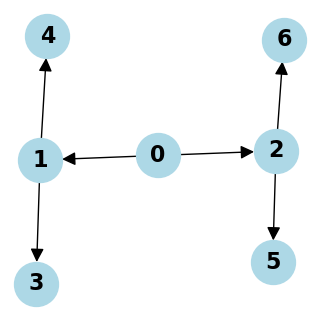

In [6]:
# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_a)
nx.draw(g_a, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

We'll get the Strongly Connected Components (SCC) from the graph and a condensed graph where the SCCs are the nodes. This new graph will be a Directed Acyclic Graph (DAG) meaning it has no cycles.

In [7]:
gc_a, scc_a = get_gc(g_a)

In [8]:
scc_a

[{3}, {4}, {1}, {5}, {6}, {2}, {0}]

In [9]:
# The condensed graph should be acyclic, which is required for the hierarchy layout.
nx.is_directed_acyclic_graph(gc_a)

True

I tried just doing something simple and plotting the condensed graph as-is. I'm wondering why the nodes are labeled differently. They don't seem to inherit the node labels from the original graph even though each node in that graph is apparently its own SCC. In fact, the order of node labeling appears to get reversed in the condensed graph. I will need to confirm that this doesn't cause any issues with the hierarchy computations. 

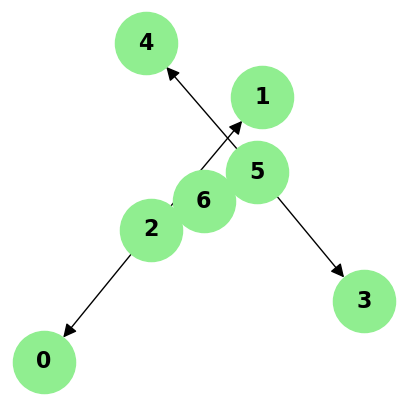

In [10]:
# plot the condensed graph
fig, ax = plt.subplots(figsize=(5, 5))
pos = nx.spring_layout(gc_a)
nx.draw(gc_a, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

In [11]:
def draw_condensed_graph(gc):
    """Draw a condensed graph with node sizes scaled by component size."""
    node_list = np.array(list(gc.nodes()))
    k_ins = dict(gc.in_degree())
    k_outs = dict(gc.out_degree())

    max_nodes = np.array([v for v in node_list if k_ins[v] == 0])
    xs = {v: 0 for v in max_nodes}
    member_dict = {v: gc.nodes[v]['members'] for v in node_list}

    prev_nodes = max_nodes.copy()
    for i in range(100):
        child_list = sum([list(gc.successors(v)) for v in prev_nodes], [])

        if not child_list:
            break

        next_nodes = np.array(list(set(child_list)))
        for v in next_nodes:
            xs[v] = i + 1

        prev_nodes = next_nodes
    else:
        raise Exception('for loop reached 100 iters')

    for v in node_list:
        if k_ins[v] == k_outs[v] == 0:
            xs[v] = np.nan

    connected_xs = [x for x in xs.values() if not np.isnan(x)]
    x_max = max(connected_xs, default=0)
    for v in node_list:
        if k_outs[v] == 0 and k_ins[v] > 0:
            xs[v] = x_max

    ys = {v: np.nan for v in node_list}
    for x_ in set(xs.values()):
        nodes_this_x = [v for v in node_list if xs[v] == x_]
        ys_ = np.random.permutation(len(nodes_this_x))
        for y_, v_ in zip(ys_, nodes_this_x):
            ys[v_] = y_ - len(nodes_this_x) / 2

    pos = {v: (xs[v], ys[v]) for v in node_list}
    alphs = np.array([len(member_dict[v]) for v in node_list])

    unconnected = [v for v in node_list if np.isnan(pos[v][0])]
    n_unconnected = len(unconnected)
    connected_xs = [x for x in xs.values() if not np.isnan(x)]
    connected_ys = [y for y in ys.values() if not np.isnan(y)]
    xr = max(connected_xs) - min(connected_xs) if connected_xs else 1
    y_max = max(connected_ys, default=0)
    x_unc = min(connected_xs, default=0) + xr / 50 * (np.arange(n_unconnected) % 50)
    y_unc = y_max * (1.25 + .05 * (np.arange(n_unconnected) // 50))

    for cv, v in enumerate(unconnected):
        pos[v] = (x_unc[cv], y_unc[cv])

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), tight_layout=True)
    nx.draw_networkx(gc, pos=pos, node_size=10, ax=ax, with_labels=False, arrows=False, arrowsize=10)
    ax.scatter(*zip(*[pos[v] for v in node_list]), s=25 * alphs, zorder=1000, c='limegreen')
    ax.set_title(f'Condensed graph ({n_unconnected} unconnected nodes)')

    return fig, ax

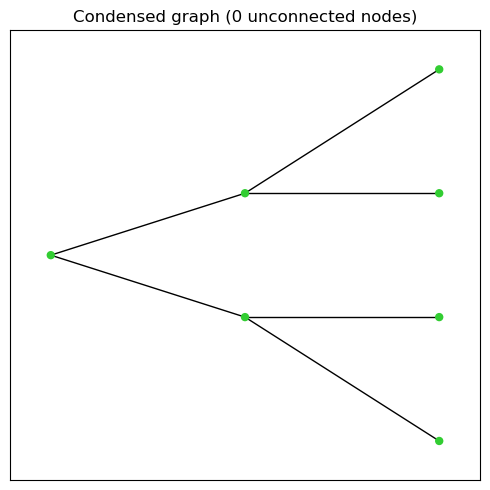

In [12]:
draw_condensed_graph(gc_a)
plt.show()

We compute the hierarchy metrics for this simple example below. 

**Treeness** (−1 ≤ T ≤ 1) tells us "how pyramidal is the structure and how unambiguous is its chain of command". This example graph is perfectly tree-like and should give T=1.

**Feedforwardness** (F, being 0 ≤ F ≤ 1) is "a measure that weights the impact of cyclic modules on the feedforward structure, where cyclic modules closer to the top of G introduce a larger penalty on hierarchical order than those placed at the bottom". This example graph should give F=1.

**Orderability** "lies in the range 0 ≤ O ≤ 1 and it is defined as the fraction of the nodes of the graph G that does not belong to any cycle". None of the nodes belongs to a cycle, so O=1 in this exmaple.

In [13]:
# treeness
t_a = calc_treeness(gc_a)[0]

# feedforwardness
f_a = calc_feedforwardness(gc_a)

# orderability
o_a = calc_orderability(gc_a)

print(f'T(A) = {t_a}, F(A) = {f_a}, O(A) = {o_a}')

T(A) = 1.0, F(A) = 1.0, O(A) = 1.0


## B: Converging feedforward graph
This is the example from Fig. 1B of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316). The metrics should be T=-1, F=1, O=1. 

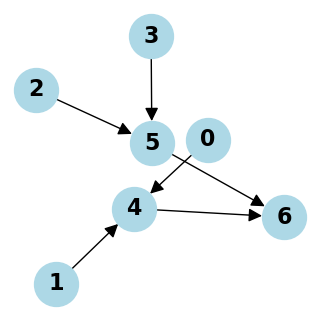

In [14]:
# adjacency matrix for a simple example graph
adj_b = np.array([
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
])

# Create a directed graph from the adjacency matrix.
g_b = nx.from_numpy_array(adj_b, create_using=nx.DiGraph)

# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_b)
nx.draw(g_b, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

In [15]:
# Compute the graph condensation.
gc_b, scc_b = get_gc(g_b)

Is there any reason to allow connections to cross? Seems messy. Try fixing this in the draw_condensed_graph function.

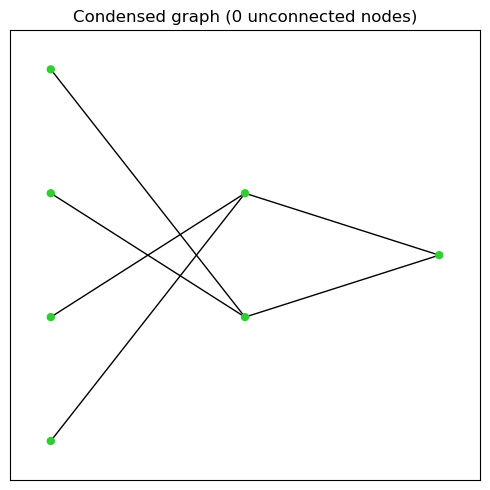

In [16]:
# draw the condensed graph
draw_condensed_graph(gc_b)
plt.show()

In [17]:
# treeness
t_b = calc_treeness(gc_b)[0]
# feedforwardness
f_b = calc_feedforwardness(gc_b)
# orderability
o_b = calc_orderability(gc_b)

print(f'T(B) = {t_b}, F(A) = {f_b}, O(B) = {o_b}')

T(B) = -1.0, F(A) = 1.0, O(B) = 1.0


## C: Converging and diverging graph
This one has no treeness even though it is perfectly feedforward and perfectly orderable. Example from Fig. 1C of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316). T=0, F=1, O=1.

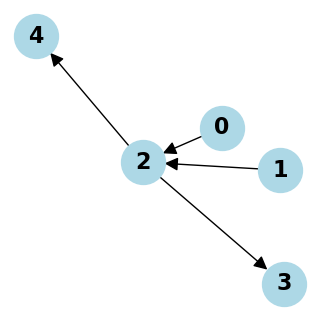

In [18]:
# adjacency matrix for a simple example graph
adj_c = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

# Create a directed graph from the adjacency matrix.
g_c = nx.from_numpy_array(adj_c, create_using=nx.DiGraph)

# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_c)
nx.draw(g_c, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

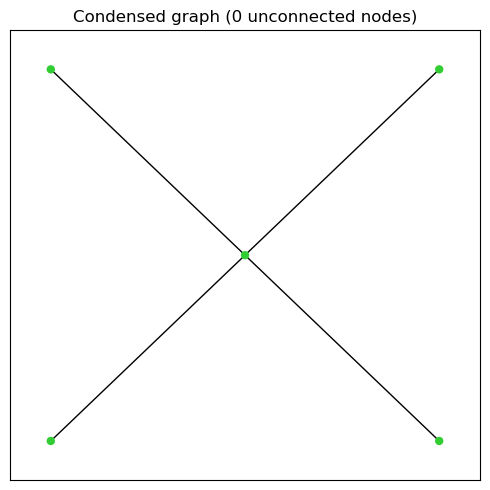

In [19]:
# Compute the graph condensation.
gc_c, scc_c = get_gc(g_c)

# draw the condensed graph
draw_condensed_graph(gc_c)
plt.show()

In [20]:
# treeness
t_c = calc_treeness(gc_c)[0]
# feedforwardness
f_c = calc_feedforwardness(gc_c)
# orderability
o_c = calc_orderability(gc_c)

print(f'T(C) = {t_c}, F(A) = {f_c}, O(C) = {o_c}')

T(C) = 0.0, F(A) = 1.0, O(C) = 1.0


## D: Graph with cycles
Now we're cooking. This graph has maximal treeness. The order of command is clear. But the SCCs are like departments. Sometimes business sticks around within a department, and it makes it harder to order the nodes.
Example from Fig. 1D of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316). T=1, F=0.6, O=0.5.

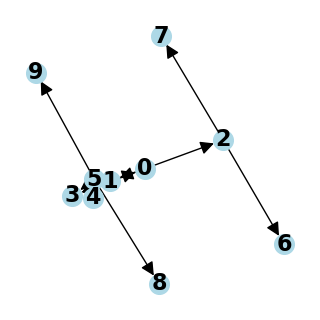

In [21]:
# adjacency matrix for a simple example graph
adj_d = np.array([
    [0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Create a directed graph from the adjacency matrix.
g_d = nx.from_numpy_array(adj_d, create_using=nx.DiGraph)

# draw the directed graph
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_d)
nx.draw(g_d, pos, with_labels=True, node_color='lightblue', node_size=200, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

Notice how the condensed graph resembles the directed graph from example A.

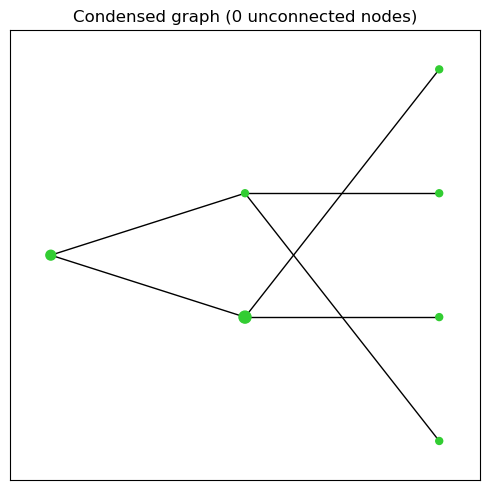

In [22]:
# compute the graph condensation.
gc_d, scc_d = get_gc(g_d)

# draw the condensed graph
draw_condensed_graph(gc_d)
plt.show()

In [23]:
# treeness
t_d = calc_treeness(gc_d)[0]
# feedforwardness
f_d = calc_feedforwardness(gc_d)
# orderability
o_d = calc_orderability(gc_d)

print(f'T(D) = {t_d}, F(A) = {f_d}, O(D) = {o_d}')

T(D) = 1.0, F(A) = 0.625, O(D) = 0.5


Should be:

`T(A) = 1.0, F(A) = 1.0, O(A) = 1.0`

`T(B) = -1.0, F(A) = 1.0, O(B) = 1.0`

`T(C) = 0.0, F(A) = 1.0, O(C) = 1.0`

`T(D) = 1.0, F(A) = 0.625, O(D) = 0.5`

## E: Graph with 1 cycle
Using the example from Fig. 14 of the supplementary material of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316), I confirmed that the Treeness and Feedforwardness calculations implemented in Baker et al (2022) are missing the higher order components of the algorithms. In that example, we should get T=-0.55, F=0.56, O=0.43. Orderability is correct because it doesn't have additional components and it is simply computed on the whole graph. However, we obtained values for T and F that are only for the first term of each calculation. 

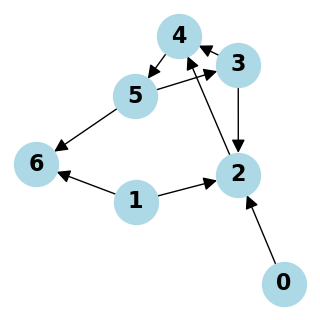

In [24]:
# adjacency matrix for a simple example graph
adj_e = np.array([
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
])

# Create a directed graph from the adjacency matrix.
g_e = nx.from_numpy_array(adj_e, create_using=nx.DiGraph)

# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_e)
nx.draw(g_e, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

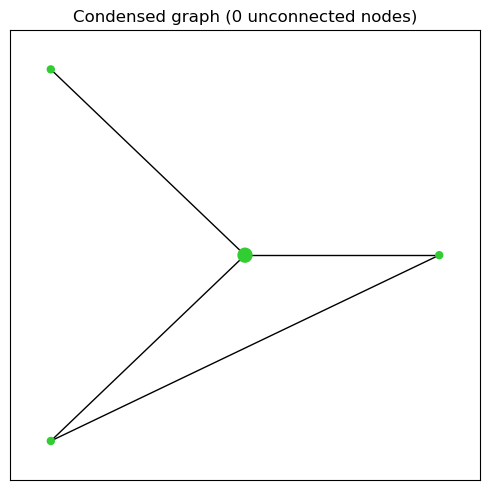

In [25]:
# compute the graph condensation.
gc_e, scc_e = get_gc(g_e)

# draw the condensed graph
draw_condensed_graph(gc_e)
plt.show()

Here, we can see that the SCCs retain the node labels from the original graph which had labels going from top down, but the condensed graphs relabels the nodes and starts bottom up. 

In [26]:
scc_e

[{6}, {2, 3, 4, 5}, {0}, {1}]

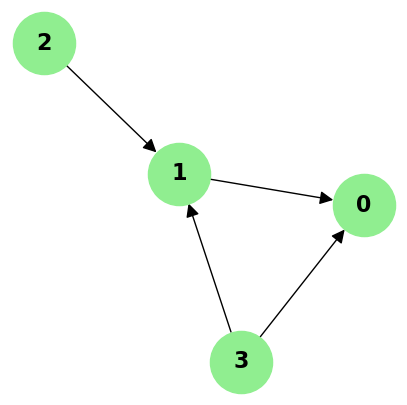

In [27]:
# plot the condensed graph
fig, ax = plt.subplots(figsize=(5, 5))
pos = nx.spring_layout(gc_e)
nx.draw(gc_e, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

In [28]:
# treeness
t_e = calc_treeness(gc_e)[0]
# feedforwardness
f_e = calc_feedforwardness(gc_e)
# orderability
o_e = calc_orderability(gc_e)

print(f'T(D) = {t_e}, F(A) = {f_e}, O(D) = {o_e}')

T(D) = -0.6666666666666666, F(A) = 0.6666666666666666, O(D) = 0.42857142857142855


In [29]:
nx.dag_longest_path_length(gc_e)

2

The forward and backward entropies appear to be computed correctly for the condensed graph, but treeness should be -0.55.

In [30]:
t_e, hf, hb = calc_treeness(gc_e)
print(t_e, hf, hb)

-0.6666666666666666 0.5 1.5


# The corrected hierarchy functions
## Treeness
The plan is to use the existing Treeness function and to nest it. The existing function computes f(G) but the complete Treeness is average f(G) over all the subgraphs including the condensed graph. 

This seems to work, do a couple more sanity checks to make sure.

In [31]:
def calc_complete_treeness(gc):
    """Return treeness. This version is corrected to include the "higher order" terms in the computation."""

    # length of the longest path in condensed graph gc
    L = nx.dag_longest_path_length(gc)

    # f(Gc): first-order term: compute treeness for entire condensed graph
    fGc = calc_treeness(gc)[0]

    # call calc_treeness on all subgraphs of gc using leaf removal, and average the results
    subgraph_treeness_LRf = []
    subgraph_treeness_LRb = []
    subgraph_LRf = gc.copy()
    subgraph_LRb = gc.copy()
    for i in range(1, L):
        # get the subgraph by removing the max nodes -> forward leaf removal
        non_max_nodes = [v for v in subgraph_LRf.nodes() if subgraph_LRf.in_degree(v) > 0]
        subgraph_LRf = subgraph_LRf.subgraph(non_max_nodes)
        subgraph_treeness_LRf.append(calc_treeness(subgraph_LRf)[0])

        # get the subgraph by removing the min nodes -> backward leaf removal
        non_min_nodes = [v for v in subgraph_LRb.nodes() if subgraph_LRb.out_degree(v) > 0]
        subgraph_LRb = subgraph_LRb.subgraph(non_min_nodes)
        subgraph_treeness_LRb.append(calc_treeness(subgraph_LRb)[0])

    # return the complete treeness that was averaged over all the subgraphs
    T = (fGc + sum(subgraph_treeness_LRf + subgraph_treeness_LRb)) / ((2 * L) - 1)
    return T #, subgraph_treeness_LRf, subgraph_treeness_LRb

In [32]:
calc_complete_treeness(gc_e)

-0.5555555555555555

All of the 4 simple examples still compute correctly with this revised treeness calculation.

In [33]:
calc_complete_treeness(gc_a), calc_complete_treeness(gc_b), calc_complete_treeness(gc_c), calc_complete_treeness(gc_d)

(1.0, -1.0, 0.0, 1.0)

## Feedforwardness
Here I also nested things, although I had to modify the original function. This version now does a complete feedforwardness computation.

In [34]:
def calc_complete_feedforwardness(gc):
    """Return complete feedforwardness: modified to return complete feedforwardness for entire graph"""

    # first-order term: compute feedforwardness for entire condensed graph
    f1 = calc_feedforwardness(gc)

    # higher-order terms: compute feedforwardness for each subgraph of the condensed graph using leaf removal
    # length of the longest path in condensed graph gc
    L = nx.dag_longest_path_length(gc)

    subgraph_LRb = gc.copy()
    subgraph_ffs = f1.copy()  # initialize the list of higher-order terms with the first-order term
    for i in range(1, L):    
        # get the subgraph by removing the min nodes -> backward leaf removal
        subgraph_LRb = subgraph_LRb.subgraph([v for v in subgraph_LRb.nodes() if subgraph_LRb.out_degree(v) > 0])

        # compute feedforwardness for the subgraph
        fh = calc_feedforwardness(subgraph_LRb)

        # append the flattened feedforwardness of the subgraph to the list of other terms
        subgraph_ffs.extend(fh)

    # take the average of the first-order and higher-order terms to get the complete feedforwardness
    feedforwardness = np.mean(subgraph_ffs)
    return feedforwardness #, f1, subgraph_ffs

def calc_feedforwardness(gc):
    """Return feedforwardness: modified to return partial feedforwardness for dissected graph"""

    # in-degrees and out-degrees of the condensed graph
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()

    # maximal nodes (no incoming edges) and minimal nodes (no outgoing edges)
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])

    # if graph is a single node or a single layer, feedforwardness is 0
    if len(max_nodes) == len(min_nodes) == len(gc):
        return 0.

    # number of members in each node of the condensed graph
    alph = {i: len(gc.nodes[i]['members']) for i in gc.nodes()}
    
    paths_all = []

    # iterate over all maximal nodes and find all paths to minimal nodes
    for v in max_nodes:
        # this returns a list of lists of paths from the max_nodes v to each u in min_nodes, as long as a path exists and as long as it's not a self-loop
        # sum() just flattens the list of lists into a single list of paths
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            continue

        # extend the paths_all list with the new paths and probabilities at each iteration
        paths_all.extend(paths)
    
    ffs = []
    
    for path in paths_all:
        # calculate the feedforwardness of each path as the length of the path divided by the sum of the number of members in each node along the path
        ffs.append(len(path)/np.sum([alph[i] for i in path]))

    # returns list of feedforward ratios
    return ffs

Feedforwardness for the examples is supposed to be:\
A: 1, B: 1, C: 1, D: 0.6, E: 0.56

In [35]:
calc_complete_feedforwardness(gc_a), calc_complete_feedforwardness(gc_b), calc_complete_feedforwardness(gc_c), calc_complete_feedforwardness(gc_d), calc_complete_feedforwardness(gc_e)

(1.0, 1.0, 1.0, 0.5944444444444444, 0.5599999999999999)

In [37]:
# for testing
subgraph_treeness = []
subgraph = gc_e.copy()
for i in range(1, 3):
    non_max_nodes = [v for v in subgraph.nodes() if subgraph.in_degree(v) > 0]
    print(f'non_max_nodes: {non_max_nodes}')
    subgraph = subgraph.subgraph(non_max_nodes)
    subgraph_treeness.append(calc_treeness(subgraph)[0])

non_max_nodes: [0, 1]
non_max_nodes: [0]


## F: Longer graph with 1 cycle
This one is similar to the graph with 1 cycle above but with an additional node that is downstream of the formerly last node. I worked the metrics out by hand for this one and the results check out with the code function.

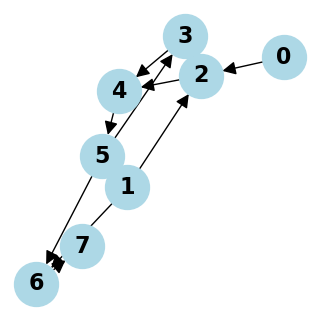

In [38]:
# adjacency matrix for a simple example graph
adj_f = np.array([
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0]
])

# Create a directed graph from the adjacency matrix.
g_f = nx.from_numpy_array(adj_f, create_using=nx.DiGraph)

# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_f)
nx.draw(g_f, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

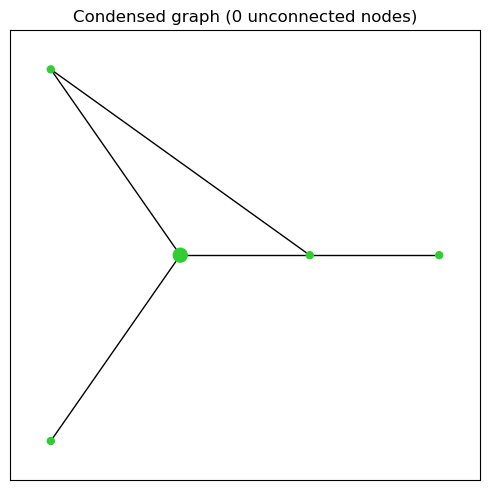

In [39]:
# compute the graph condensation.
gc_f, scc_f = get_gc(g_f)

# draw the condensed graph
draw_condensed_graph(gc_f)
plt.show()

In [40]:
scc_f

[{7}, {6}, {2, 3, 4, 5}, {0}, {1}]

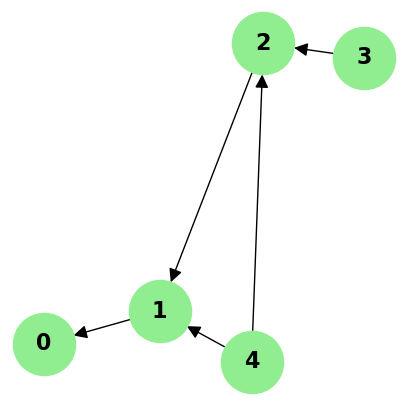

In [41]:
# plot the condensed graph
fig, ax = plt.subplots(figsize=(5, 5))
pos = nx.spring_layout(gc_f)
nx.draw(gc_f, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

In [42]:
# treeness
t_f = calc_treeness(gc_f)[0]
# feedforwardness
f_f = np.mean(calc_feedforwardness(gc_f))
# orderability
o_f = calc_orderability(gc_f)

print(f'T(D) = {t_f}, F(A) = {f_f}, O(D) = {o_f}')

T(D) = -0.6666666666666666, F(A) = 0.7142857142857143, O(D) = 0.5


The forward and backward entropies on the full condensed graph are not affected by the additonal node. I think that makes sense because the addition of the last node did not add any new paths (i.e. no new branches were created).

In [43]:
t_f, hf, hb = calc_treeness(gc_f)
print(t_f, hf, hb)

-0.6666666666666666 0.5 1.5


The treeness is closer to 0 with this additional node than for graph E. Maybe that makes sense because the graph is longer and less pyramidal. The feedforwardness is reduced -- I think because the cyclic module is closer to the top than before. To make sure about these, I computed T by hand and this is true.

In [44]:
calc_complete_treeness(gc_f), calc_complete_feedforwardness(gc_f), calc_orderability(gc_f)

(-0.4666666666666666, 0.6178571428571429, 0.5)

In [45]:
calc_complete_treeness(gc_e), calc_complete_feedforwardness(gc_e), calc_orderability(gc_e)

(-0.5555555555555555, 0.5599999999999999, 0.42857142857142855)

In [46]:
((8/7)+3+(4/5))/8

0.6178571428571428

In [57]:
(-0.6666-0.6666-1)/5

-0.46663999999999994